# Ames Housing Price Prediction - Modelling

## 1. Modelling Overview

In the previous notebook, I performed the exploratory data analysis to understand the main patterns behind house prices in the Ames Housing dataset.

The EDA showed that SalePrice is right-skewed, that quality and size-related features are strong price drivers, and that missing values and outliers need to be handled carefully before training the models.

In this notebook, I will transform those insights into a complete Machine Learning pipeline. The main goal is to prepare the data properly, train different regression models, compare their performance and select the best final model to predict house sale prices.

The main steps in this notebook are:

1. Load the dataset.
2. Split the data into training and test sets.
3. Clean the data based on the EDA findings.
4. Create engineered features.
5. Preprocess numerical and categorical variables.
6. Train and compare different regression models.
7. Tune the best-performing model.
8. Evaluate the final model on the test set.
9. Save the final model and prediction outputs.

The training data will be used for preprocessing decisions, feature engineering, model training and model selection. The test data will remain untouched until the final evaluation, helping ensure that the final performance estimate is based on unseen data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
import importlib
import joblib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
sys.path.append('../src')

In [2]:
from feature_engineering import create_features
from feature_engineering import evaluate_model_cv
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

In [3]:
main_color = "#0B1F33"       # Dark navy
secondary_color = "#7F8C96"  # Soft blue-gray
accent_color = "#1F77B4"     # Blue
positive_color = "#2A9D8F"   # Teal
warning_color = "#E76F51"    # Terracotta
grid_color = "#EAEAEA"       # Light gray

project_palette = [main_color, secondary_color, accent_color, positive_color, warning_color]

sns.set_theme(style="whitegrid", palette=project_palette, font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["grid.color"] = grid_color
plt.rcParams["axes.labelcolor"] = main_color
plt.rcParams["xtick.color"] = main_color
plt.rcParams["ytick.color"] = main_color

## 2. Load Dataset

In this section, I will load the original Ames Housing dataset.

At this stage, no transformations will be applied yet. I want to keep the raw dataset unchanged so that all preprocessing steps, feature engineering and modeling decisions can be clearly documented later in this notebook.

This also helps make the workflow easier to reproduce and understand.

In [4]:
df = pd.read_csv("../input/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

The dataset contains 2,930 rows and 82 columns, including the target variable SalePrice.

The next step will be to separate the target variable from the predictors and create the train-test split before applying any preprocessing or modeling steps.

## 3. Train-Test Split

Before applying any preprocessing or model training step, I will split the dataset into training and test sets.

The training set will be used for data cleaning, feature engineering, preprocessing, model training and model comparison. The test set will remain untouched and will only be used at the end to evaluate the final selected model.

This approach helps prevent data leakage and gives a more realistic estimate of how the model may perform on unseen data.

In [6]:
target = 'SalePrice'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


In [7]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
y_train_clean = y_train.copy()
y_test_clean = y_test.copy()

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 81)
X_test_clean shape: (586, 81)


The dataset was split using an 80/20 proportion:

- Training set: 2,344 rows and 81 predictive features
- Test set: 586 rows and 81 predictive features

From this point forward, all cleaning, preprocessing, feature engineering and model selection steps will be based only on the training data. The test set will stay untouched until the final evaluation.

## 4. Modeling Workflow

Before training the models, I will prepare the data through a structured modeling workflow.

The main goal is to make sure that all transformations are applied correctly, using only the training data when fitting preprocessing steps. This helps avoid data leakage and makes the final test evaluation more reliable.

The workflow will follow these steps:

1. Remove unnecessary identifier columns.
2. Handle potential outliers in the training data.
3. Treat missing values according to their meaning.
4. Create engineered features based on the EDA insights.
5. Encode categorical variables.
6. Scale numerical variables when required by the model.
7. Train a baseline model.
8. Compare multiple regression models using cross-validation.
9. Tune the best-performing model.
10. Evaluate the final model on the untouched test set.

This structure keeps the modeling process organized and makes each decision easier to track and reproduce.

## 5. Data Cleaning

In this section, I will start cleaning the dataset before preprocessing and model training.

The first step is to remove identifier columns that do not provide predictive information to the model.

Columns such as Order and PID are useful for identifying records, but they should not be used as input features for machine learning models because they do not represent real property characteristics.

In [8]:
identifier_columns = ['Order', 'PID']
[col for col in identifier_columns if col in X_train_clean.columns]

['Order', 'PID']

In [9]:
X_train_clean = X_train_clean.drop(columns=identifier_columns)
X_test_clean = X_test_clean.drop(columns=identifier_columns)

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 79)
X_test_clean shape: (586, 79)


In [10]:
[col for col in identifier_columns if col in X_train_clean.columns]

[]

### 5.1 Outlier Treatment

Based on the EDA, a few observations with extremely high Gr Liv Area may behave as influential outliers.

These houses have very large above-ground living areas, but some of them have relatively low sale prices compared to properties with similar size. This pattern can strongly affect regression models, especially linear models.

For this reason, I will remove these specific observations only from the training set. The test set will remain untouched, so the final evaluation still represents unseen real-world data.

In [11]:
train_clean_check = X_train_clean.copy()
train_clean_check["SalePrice"] = y_train_clean
gr_liv_area_outliers = train_clean_check[train_clean_check["Gr Liv Area"] > 4000]
gr_liv_area_outliers[
    [
        "Gr Liv Area",
        "SalePrice",
        "Overall Qual",
        "Neighborhood"
    ]
].sort_values(by="Gr Liv Area", ascending=False)

,Gr Liv Area,SalePrice,Overall Qual,Neighborhood
1498,5642,160000,10,Edwards
2180,5095,183850,10,Edwards
1760,4476,745000,10,NoRidge
1767,4316,755000,10,NoRidge


In [12]:
outlier_indexes = X_train_clean[X_train_clean["Gr Liv Area"] > 4000].index
print(f"Number of outliers to remove: {len(outlier_indexes)}")

X_train_clean = X_train_clean.drop(index=outlier_indexes)
y_train_clean = y_train_clean.drop(index=outlier_indexes)

print(f"X_train_clean shape after outlier removal: {X_train_clean.shape}")
print(f"y_train_clean shape after outlier removal: {y_train_clean.shape}")

Number of outliers to remove: 4
X_train_clean shape after outlier removal: (2340, 79)
y_train_clean shape after outlier removal: (2340,)


In [13]:
print(f"X_test_clean shape: {X_test_clean.shape}")
print(f"y_test_clean shape: {y_test_clean.shape}")

X_test_clean shape: (586, 79)
y_test_clean shape: (586,)


### Data Cleaning Notes

The identifier columns Order and PID were removed from both the training and test sets.

Four observations with Gr Liv Area greater than 4000 were removed from the training set.

These observations were identified during the EDA as potentially influential outliers because they had unusually large living areas compared to most houses in the dataset.

The test set was not modified during this step. This is important because the test set should remain untouched until the final evaluation, helping measure how well the final model generalizes to unseen data.

## 6. Feature Engineering

In this section, I will create new features based on the insights found during the exploratory data analysis.

The goal is to create variables that better represent property size, age, renovation status, bathroom capacity and the presence of important property characteristics.

The same transformations will be applied to both the training and test sets to keep the datasets consistent and avoid mismatches during preprocessing and model training.

In [14]:
X_train_fe = create_features(X_train_clean)
X_test_fe = create_features(X_test_clean)

print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")

X_train_fe shape: (2340, 87)
X_test_fe shape: (586, 87)


In [15]:
engineered_features = ["TotalSF","HouseAge","RemodAge","TotalBath","HasGarage","HasBasement","HasFireplace","HasPool"]
X_train_fe[engineered_features].head()

,TotalSF,HouseAge,RemodAge,TotalBath,HasGarage,HasBasement,HasFireplace,HasPool
381,2460.0,33,33,2.0,1,1,1,0
834,3139.0,42,42,3.0,1,1,0,0
1898,1224.0,45,45,2.0,1,0,0,0
678,1040.0,60,59,2.0,1,0,0,0
700,2301.0,89,59,2.0,0,1,0,0


In [16]:
same_columns = X_train_fe.columns.equals(X_test_fe.columns)

print(f"Train and test have the same columns: {same_columns}")

Train and test have the same columns: True


In [17]:
train_fe_analysis = X_train_fe.copy()
train_fe_analysis["SalePrice"] = y_train_clean
engineered_corr = train_fe_analysis[engineered_features + ["SalePrice"]].corr()["SalePrice"]
engineered_corr = engineered_corr.sort_values(ascending=False)
engineered_corr

SalePrice       1.000000
TotalSF         0.813423
TotalBath       0.642083
HasFireplace    0.477883
HasGarage       0.224693
HasBasement     0.162707
HasPool         0.068039
RemodAge       -0.529361
HouseAge       -0.554716
Name: SalePrice, dtype: float64

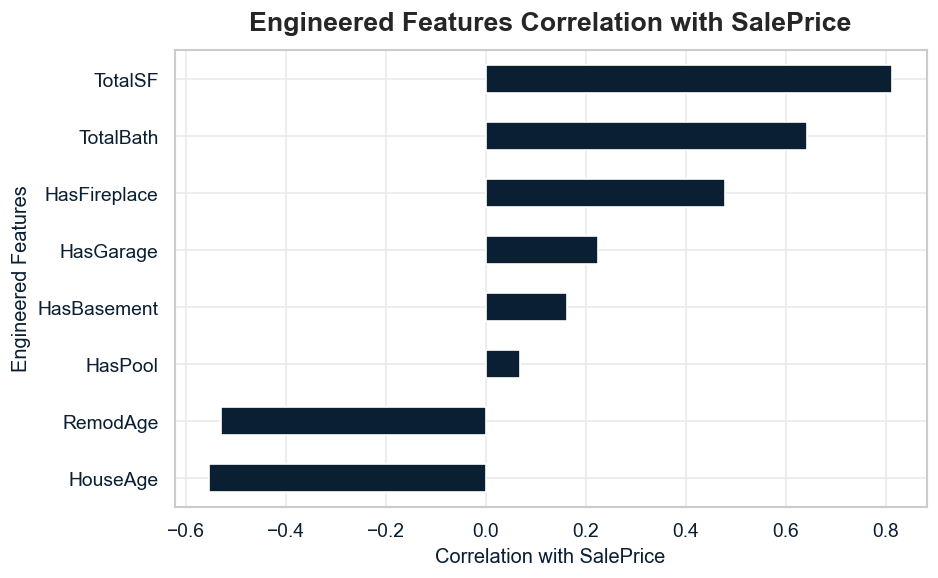

In [18]:
engineered_corr_without_target = engineered_corr.drop("SalePrice")

plt.figure(figsize=(8, 5), dpi=120)
engineered_corr_without_target.sort_values().plot(kind="barh")
plt.title(
    "Engineered Features Correlation with SalePrice",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Correlation with SalePrice", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
negative_house_age = (X_train_fe["HouseAge"] < 0).sum()
negative_remod_age = (X_train_fe["RemodAge"] < 0).sum()

print(f"Negative HouseAge values: {negative_house_age}")
print(f"Negative RemodAge values: {negative_remod_age}")

Negative HouseAge values: 0
Negative RemodAge values: 0


### Feature Engineering Notes

New features were created to better represent important property characteristics identified during the exploratory data analysis.

TotalSF combines basement area, first floor area and second floor area into a single measure of overall property size. This feature shows a strong relationship with SalePrice, which makes sense because larger houses tend to be more valuable.

HouseAge and RemodAge represent the age of the house and the time since the last remodeling. Both features help capture how new or recently updated a property is.

TotalBath summarizes the bathroom capacity of the house by combining full bathrooms and half bathrooms, including basement bathrooms.

Binary features such as HasGarage, HasBasement, HasFireplace and HasPool indicate the presence or absence of important property characteristics. These features may help the model capture structural differences between houses.

After feature engineering, the training and test sets were checked to make sure they still have the same columns. These engineered features will be included in the preprocessing and modeling pipeline.

## 7. Missing Value Treatment

In this section, I will define how missing values will be treated before model training.

The Ames Housing dataset has different types of missing values. Some of them represent the absence of a property characteristic, such as no garage, no basement, no fireplace, no pool, no fence or no alley access. These values should be treated as meaningful information instead of simple data errors.

For categorical variables where missing values mean absence, I will fill them with "None". For numerical variables related to absent structures, such as garage area, basement area or masonry veneer area, I will fill missing values with "0".

Other missing values represent unknown information. These will be handled with statistical imputation, using the median for numerical features and the most frequent category for categorical features.

All these preprocessing steps will be included in a **ColumnTransformer**. This helps keep the workflow organized and ensures that the transformations can be applied consistently to both training and test data.

In [20]:
missing_train = X_train_fe.isna().sum()
missing_train = missing_train[missing_train > 0]
missing_train = missing_train.sort_values(ascending=False)
missing_train

Pool QC           2330
Misc Feature      2247
Alley             2178
Fence             1871
Mas Vnr Type      1425
Fireplace Qu      1144
Lot Frontage       393
Garage Yr Blt      122
Garage Cond        122
Garage Qual        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Bsmt Full Bath       1
dtype: int64

In [21]:
categorical_features = X_train_fe.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

Categorical features: 43
Numerical features: 40


In [22]:
categorical_none_features = ["Pool QC","Misc Feature","Alley","Fence",
    "Fireplace Qu","Garage Type","Garage Finish","Garage Qual",
    "Garage Cond","Bsmt Qual","Bsmt Cond","Bsmt Exposure",
    "BsmtFin Type 1","BsmtFin Type 2","Mas Vnr Type"
]

categorical_none_features = [col for col in categorical_none_features if col in X_train_fe.columns]
categorical_mode_features = [col for col in categorical_features if col not in categorical_none_features]

print(f"Categorical None features: {len(categorical_none_features)}")
print(f"Categorical mode features: {len(categorical_mode_features)}")

Categorical None features: 15
Categorical mode features: 28


In [23]:
numeric_zero_features = ["Mas Vnr Area","Garage Yr Blt","Garage Cars",
    "Garage Area","BsmtFin SF 1","BsmtFin SF 2","Bsmt Unf SF",
    "Total Bsmt SF","Bsmt Full Bath","Bsmt Half Bath"
]

numeric_zero_features = [col for col in numeric_zero_features if col in X_train_fe.columns]
numeric_median_features = [col for col in numerical_features if col not in numeric_zero_features]

print(f"Numeric zero features: {len(numeric_zero_features)}")
print(f"Numeric median features: {len(numeric_median_features)}")

Numeric zero features: 10
Numeric median features: 30


In [24]:
binary_features = ["HasGarage","HasBasement","HasFireplace","HasPool"]
print(f"Binary features: {len(binary_features)}")

Binary features: 4


In [25]:
all_selected_features = (
    categorical_none_features +
    categorical_mode_features +
    numeric_zero_features +
    numeric_median_features +
    binary_features
)

print(f"Total columns in X_train_fe: {X_train_fe.shape[1]}")
print(f"Total selected features: {len(all_selected_features)}")

missing_from_groups = [col for col in X_train_fe.columns if col not in all_selected_features]
missing_from_groups

Total columns in X_train_fe: 87
Total selected features: 87


[]

In [26]:
numeric_zero_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

numeric_median_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_none_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_mode_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", numeric_zero_transformer, numeric_zero_features),
        ("num_median", numeric_median_transformer, numeric_median_features),
        ("binary", binary_transformer, binary_features),
        ("cat_none", categorical_none_transformer, categorical_none_features),
        ("cat_mode", categorical_mode_transformer, categorical_mode_features)
    ],
    remainder="drop"
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (2340, 321)
X_test_processed shape: (586, 321)


In [29]:
train_missing_after_processing = np.isnan(X_train_processed).sum()
test_missing_after_processing = np.isnan(X_test_processed).sum()

print(f"Missing values in processed training data: {train_missing_after_processing}")
print(f"Missing values in processed test data: {test_missing_after_processing}")

Missing values in processed training data: 0
Missing values in processed test data: 0


### Missing Value Treatment Notes

Missing values were treated according to their meaning.

For model training and cross-validation, this preprocessor will be used inside a full pipeline together with each regression model. This is important to avoid data leakage and ensure that preprocessing steps are learned only from the appropriate training folds.

## 8. Baseline Models

In this section, I will create baseline models to establish initial performance references.

The first baseline is a Dummy Regressor, which predicts the median sale price for every house. This model does not learn any relationship from the input features, so it works as a naive benchmark.

The second baseline is a Ridge Regression model. Ridge is a regularized linear model that applies L2 regularization, helping reduce the impact of large coefficients and multicollinearity.

A standard Linear Regression model will not be used as the main linear baseline because the preprocessing step creates many one-hot encoded categorical features. This increases dimensionality and may introduce multicollinearity, making an unregularized linear model less stable.

For this reason, Ridge Regression will be used as a stronger and more reliable linear baseline.

In [30]:
dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

In [31]:
dummy_results = evaluate_model_cv(
    dummy_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

dummy_results

{'MAE': 53692.479059829064,
 'RMSE': 77452.25524016068,
 'R2': -0.059035919404605154}

In [32]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [33]:
ridge_results = evaluate_model_cv(
    ridge_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

ridge_results

{'MAE': 15037.561162068425,
 'RMSE': 21766.91362360212,
 'R2': 0.9159399709148477}

In [34]:
baseline_results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Ridge Regression"],
    "MAE": [dummy_results["MAE"], ridge_results["MAE"]],
    "RMSE": [dummy_results["RMSE"], ridge_results["RMSE"]],
    "R2": [dummy_results["R2"], ridge_results["R2"]]
})

baseline_results = baseline_results.sort_values(by="RMSE", ascending=True)
baseline_results

,Model,MAE,RMSE,R2
1,Ridge Regression,15037.561162,21766.913624,0.915940
0,Dummy Regressor,53692.479060,77452.255240,-0.059036


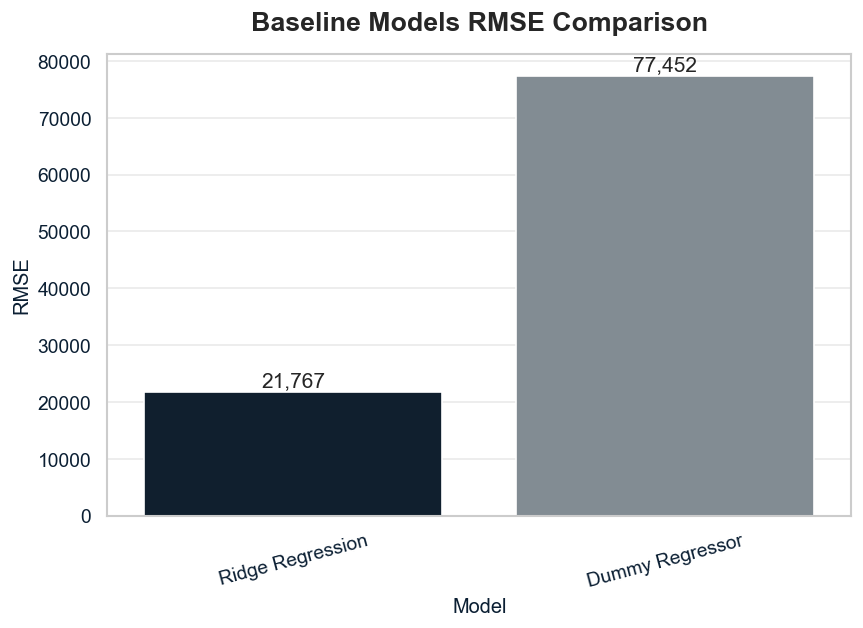

In [35]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=baseline_results,
    x="Model",
    y="RMSE"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:,.0f}" for value in baseline_results["RMSE"]],
        padding=1
    )

plt.title("Baseline Models RMSE Comparison", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.xticks(rotation=15)
plt.show()

### Baseline Model Notes

The Dummy Regressor was used as a naive baseline. It predicts the median sale price for every property and does not learn any relationship from the input features.

Ridge Regression performed much better than the Dummy Regressor, which shows that the dataset contains useful predictive patterns for estimating house prices.

Instead of using a standard Linear Regression model, Ridge Regression was selected as the linear baseline because it applies L2 regularization. This is useful in this project because the preprocessing step creates many one-hot encoded features, which can increase dimensionality and multicollinearity.

The strong improvement from the Dummy Regressor to Ridge Regression confirms that the features are informative and that it makes sense to continue with more advanced regression models.

## 9. Model Comparison

In this section, I will compare multiple regression models using the same preprocessing pipeline and 5-fold cross-validation.

The goal is to identify which model provides the best predictive performance before moving to hyperparameter tuning.

All models will use the same preprocessing steps to ensure a fair comparison. The Dummy Regressor will also be kept as a naive baseline, but the main comparison will focus on models that actually learn patterns from the data.

In [36]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),                                                           # Ridge Regression is a regularized linear model using L2 penalty
    #"Lasso Regression": Lasso(alpha=0.1, max_iter=200000, tol=1e-3, random_state=42),               # Lasso Regression is a regularized linear model using L1 penalty
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=200000, tol=1e-3, random_state=42),  # ElasticNet combines L1 and L2 regularization
    "Random Forest": RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1),             # Random Forest is an ensemble of decision trees
    "Extra Trees": ExtraTreesRegressor(n_estimators=300,random_state=42,n_jobs=-1),                 # Extra Trees is a more randomized tree-based ensemble
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)                                 # Gradient Boosting builds trees sequentially to reduce errors
}                        

In [37]:
model_results_list = []

for model_name, model in models.items():
    
    model_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])
    results = evaluate_model_cv(model_pipeline,X_train_fe,y_train_clean,cv=5)
    model_results_list.append({
        "Model": model_name,
        "MAE": results["MAE"],
        "RMSE": results["RMSE"],
        "R2": results["R2"]
    })

model_comparison = pd.DataFrame(model_results_list)
model_comparison = model_comparison.sort_values(by="RMSE", ascending=True)
model_comparison

,Model,MAE,RMSE,R2
4,Gradient Boosting,14111.416887,21148.199102,0.920390
0,Ridge Regression,15037.561162,21766.913624,0.915940
1,ElasticNet,15015.924138,22054.322646,0.913873
3,Extra Trees,14661.402699,22549.278337,0.910152
2,Random Forest,15421.348246,23415.077210,0.902813


In [38]:
dummy_baseline_row = pd.DataFrame({
    "Model": ["Dummy Regressor"],
    "MAE": [dummy_results["MAE"]],
    "RMSE": [dummy_results["RMSE"]],
    "R2": [dummy_results["R2"]]
})

full_model_comparison = pd.concat(
    [model_comparison, dummy_baseline_row],
    ignore_index=True
)

full_model_comparison = full_model_comparison.sort_values(by="RMSE", ascending=True)
full_model_comparison

,Model,MAE,RMSE,R2
0,Gradient Boosting,14111.416887,21148.199102,0.920390
1,Ridge Regression,15037.561162,21766.913624,0.915940
2,ElasticNet,15015.924138,22054.322646,0.913873
3,Extra Trees,14661.402699,22549.278337,0.910152
4,Random Forest,15421.348246,23415.077210,0.902813
5,Dummy Regressor,53692.479060,77452.255240,-0.059036


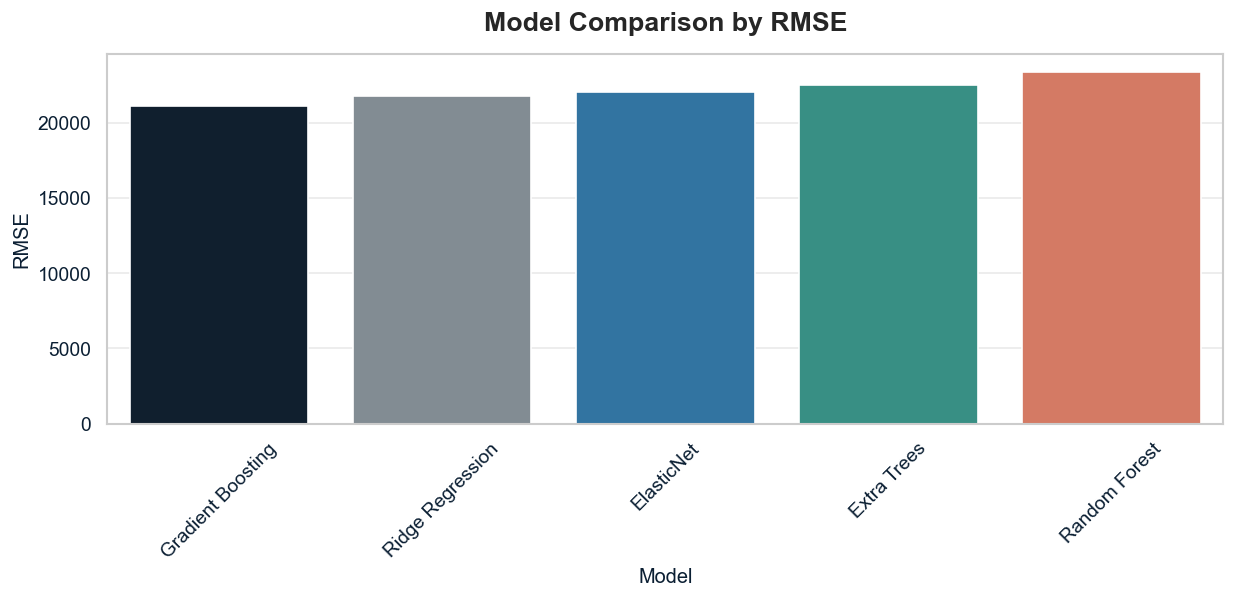

In [39]:
plt.figure(figsize=(12, 4))
sns.barplot(data=model_comparison,x="Model",y="RMSE")
plt.title("Model Comparison by RMSE", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.xticks(rotation=45)
plt.show()

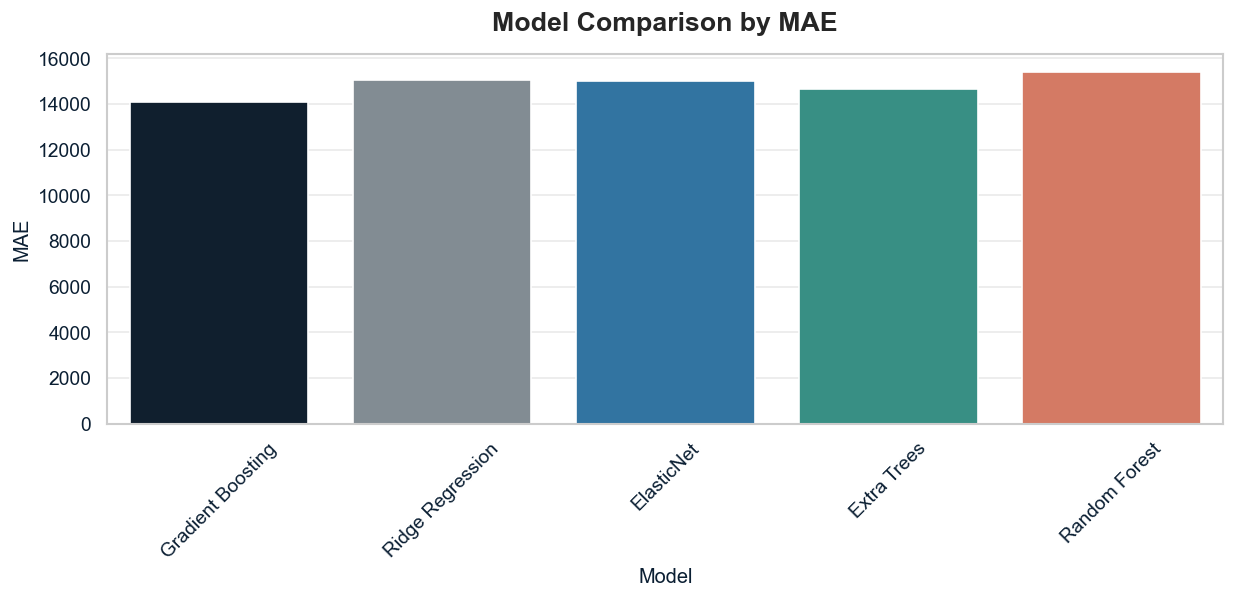

In [40]:
plt.figure(figsize=(12, 4))
sns.barplot(data=model_comparison,x="Model",y="MAE")
plt.title("Model Comparison by MAE", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [41]:
best_model_name = full_model_comparison.iloc[0]["Model"]
best_model_rmse = full_model_comparison.iloc[0]["RMSE"]
best_model_mae = full_model_comparison.iloc[0]["MAE"]
best_model_r2 = full_model_comparison.iloc[0]["R2"]

print(f"Best model: {best_model_name}")
print(f"Best RMSE: {best_model_rmse:,.2f}")
print(f"Best MAE: {best_model_mae:,.2f}")
print(f"Best R2: {best_model_r2:.4f}")

Best model: Gradient Boosting
Best RMSE: 21,148.20
Best MAE: 14,111.42
Best R2: 0.9204


### Model Comparison Notes

Multiple regression models were evaluated using the same preprocessing pipeline and 5-fold cross-validation.

The Dummy Regressor was kept as a naive baseline to confirm whether the machine learning models were actually learning useful patterns from the data. Since all trained models performed much better than the Dummy Regressor, this confirms that the dataset contains strong predictive signal for house price estimation.

Among the tested models, Gradient Boosting achieved the best cross-validation performance based on RMSE. This suggests that boosting is able to capture important non-linear relationships between house characteristics and sale prices.

Ridge Regression and ElasticNet also performed well, showing that regularized linear models can provide strong and stable baselines, especially after preprocessing and one-hot encoding.

Tree-based ensemble models such as Random Forest, Extra Trees and Gradient Boosting are useful because they can capture more complex interactions between features. However, the final choice should still consider performance, stability and tuning potential.

Based on the cross-validation results, the best-performing model will be selected for hyperparameter tuning in the next section.

## 10. Hyperparameter Tuning

The best-performing model from the model comparison step was Gradient Boosting.

In this section, I will tune the Gradient Boosting model using cross-validation on the training data only.

The goal is to test different combinations of hyperparameters and improve the model performance before evaluating it on the final test set.

The test set will remain untouched during this step and will only be used in the final evaluation.

In [42]:
gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [43]:
gb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0]
}

In [44]:
gb_random_search = RandomizedSearchCV(
    estimator=gradient_boosting_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [45]:
gb_random_search.fit(X_train_fe, y_train_clean)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num_zero',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Mas '
                                                                                'Vnr '
                                                                                'Area',
                                                                                'Garage '
                                                                                'Yr '
                                                                                'Blt',
                                                                                'Garage '
                                                                                'Cars',
                                                                                'Garage '
                                                                                'Area',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '1',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '2',
                                                                                'Bsmt '
                                                                                'Unf '
                                                                                'SF',
                                                                                'Total '
                                                                                'Bsmt '
                                                                                'SF',...
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [46]:
gb_random_search.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 500,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 4,
 'model__max_depth': 3,
 'model__learning_rate': 0.1}

In [47]:
best_gb_cv_rmse = -gb_random_search.best_score_

print(f"Best Gradient Boosting CV RMSE: {best_gb_cv_rmse:,.2f}")

Best Gradient Boosting CV RMSE: 20,315.60


In [48]:
best_gb_model = gb_random_search.best_estimator_
best_gb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_zero',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Mas Vnr Area',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath']),
                                                 ('num_median',
                                                  Pipeline(steps=[...
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air', 'Electrical',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Sale Type',
                                                   'Sale Condition'])])),
                ('model',
                 GradientBoostingRegressor(min_samples_leaf=4,
                                           min_samples_split=5,
                                           n_estimators=500, random_state=42,
                                           subsample=0.9))])

In [49]:
gb_before_tuning_rmse = 21166.19
gb_after_tuning_rmse = best_gb_cv_rmse
rmse_improvement = gb_before_tuning_rmse - gb_after_tuning_rmse
rmse_improvement_pct = (rmse_improvement / gb_before_tuning_rmse) * 100


print(f"Gradient Boosting RMSE before tuning: {gb_before_tuning_rmse:,.2f}")
print(f"Gradient Boosting RMSE after tuning: {gb_after_tuning_rmse:,.2f}")
print(f"RMSE improvement: {rmse_improvement:,.2f}")
print(f"RMSE improvement percentage: {rmse_improvement_pct:.2f}%")

Gradient Boosting RMSE before tuning: 21,166.19
Gradient Boosting RMSE after tuning: 20,315.60
RMSE improvement: 850.59
RMSE improvement percentage: 4.02%


### Hyperparameter Tuning Notes

Hyperparameter tuning was performed on the Gradient Boosting model because it achieved the best cross-validation performance during the model comparison step.

The tuning process tested different combinations of n_estimators, learning_rate, max_depth, min_samples_split, min_samples_leaf and subsample.

The model was evaluated using 5-fold cross-validation, with RMSE as the main metric. This keeps the tuning process consistent with the model comparison step.

After tuning, the Gradient Boosting model achieved a lower cross-validation RMSE, showing that the hyperparameter search improved the model performance.

The test set was not used during this step. It will only be used in the final evaluation stage after the best model has been selected.

## 11. Final Model Evaluation

In this section, I will evaluate the tuned Gradient Boosting model on the test set.

The test set remained untouched during the entire training, model comparison and hyperparameter tuning process. Because of that, this final evaluation gives a more realistic estimate of how the model may perform on unseen data.

The main metrics used are MAE, RMSE and R². I will also analyze prediction errors to better understand where the model performs well and where it still struggles.

In [50]:
y_test_pred = best_gb_model.predict(X_test_fe)
y_test_pred[:10]

array([177334.05299969, 106664.75300259, 189091.23572798, 126757.77223019,
       118804.33573554, 173798.29660837, 170936.49664733, 148466.03327718,
        93028.1595749 , 387728.18751781])

In [51]:
final_mae = mean_absolute_error(y_test_clean, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test_clean, y_test_pred))
final_r2 = r2_score(y_test_clean, y_test_pred)

print(f"Final Test MAE: ${final_mae:,.2f}")
print(f"Final Test RMSE: ${final_rmse:,.2f}")
print(f"Final Test R2: {final_r2:.4f}")

Final Test MAE: $13,549.08
Final Test RMSE: $26,044.03
Final Test R2: 0.9154


In [52]:
final_performance_comparison = pd.DataFrame({
    "Evaluation Step": ["Cross-Validation", "Final Test Set"],
    "RMSE": [best_gb_cv_rmse, final_rmse]
})

final_performance_comparison

,Evaluation Step,RMSE
0,Cross-Validation,20315.600801
1,Final Test Set,26044.028878


In [53]:
prediction_results = pd.DataFrame({
    "Actual SalePrice": y_test_clean,
    "Predicted SalePrice": y_test_pred
})

prediction_results["Error"] = prediction_results["Actual SalePrice"] - prediction_results["Predicted SalePrice"]
prediction_results["Absolute Error"] = prediction_results["Error"].abs()
prediction_results.head()

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
1357,161000,177334.053000,-16334.053000,16334.053000
2367,116000,106664.753003,9335.246997,9335.246997
2822,196500,189091.235728,7408.764272,7408.764272
2126,123600,126757.772230,-3157.772230,3157.772230
1544,126000,118804.335736,7195.664264,7195.664264


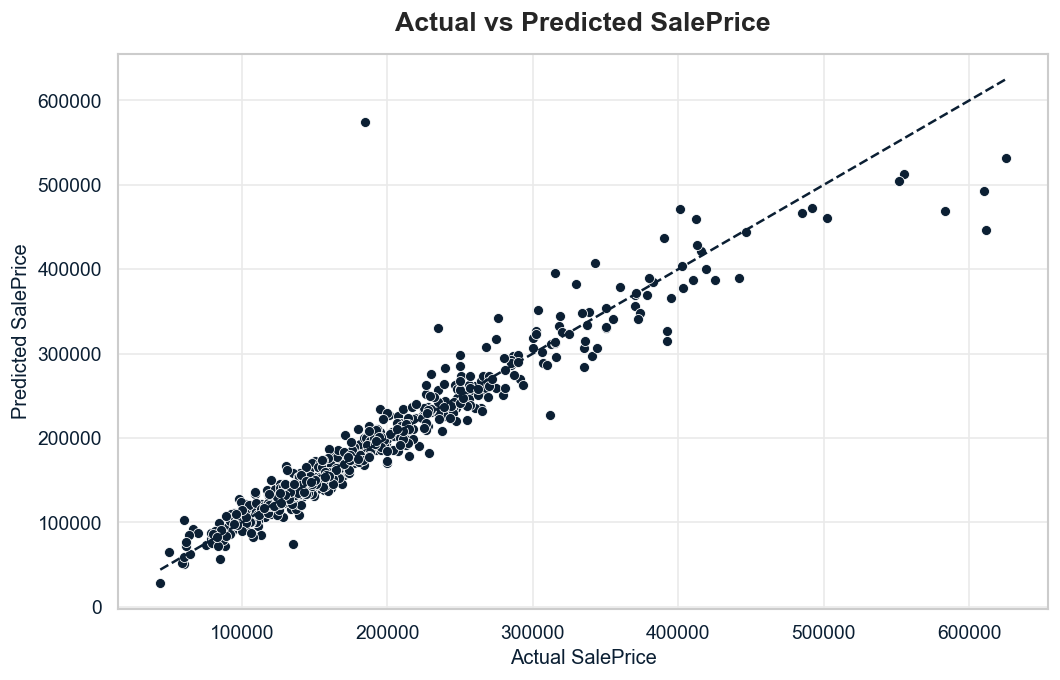

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=prediction_results["Actual SalePrice"],y=prediction_results["Predicted SalePrice"])
plt.plot(
    [prediction_results["Actual SalePrice"].min(), prediction_results["Actual SalePrice"].max()],
    [prediction_results["Actual SalePrice"].min(), prediction_results["Actual SalePrice"].max()],
    linestyle="--"
)
plt.title("Actual vs Predicted SalePrice", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Actual SalePrice", fontsize=12)
plt.ylabel("Predicted SalePrice", fontsize=12)
plt.show()

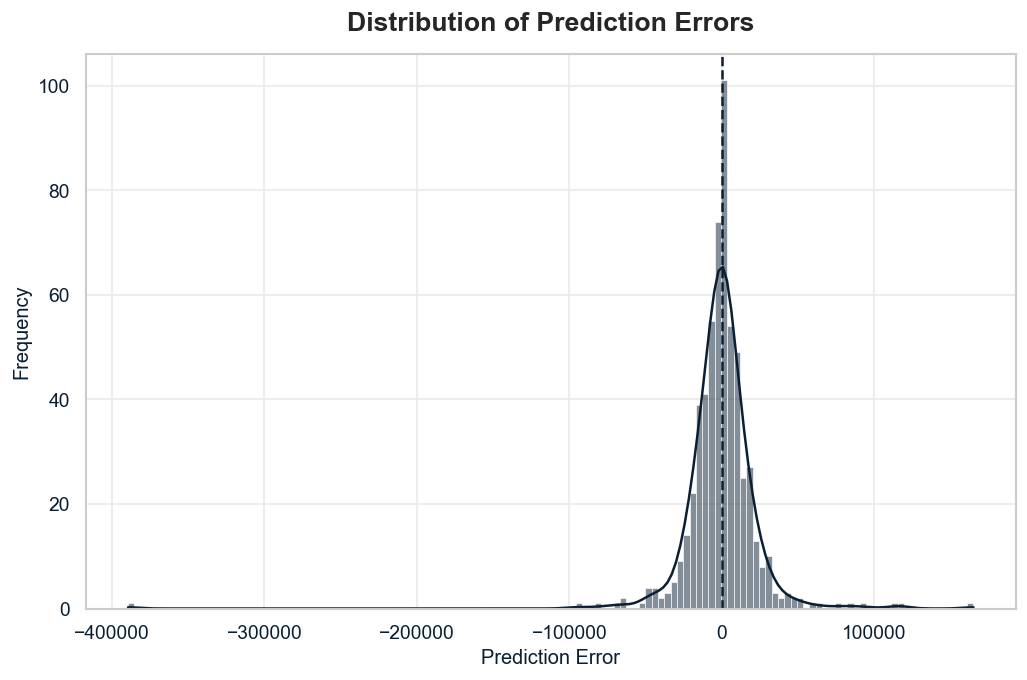

In [55]:
plt.figure(figsize=(10, 6))
sns.histplot(prediction_results["Error"], kde=True)
plt.axvline(x=0, linestyle="--")
plt.title("Distribution of Prediction Errors", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Prediction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

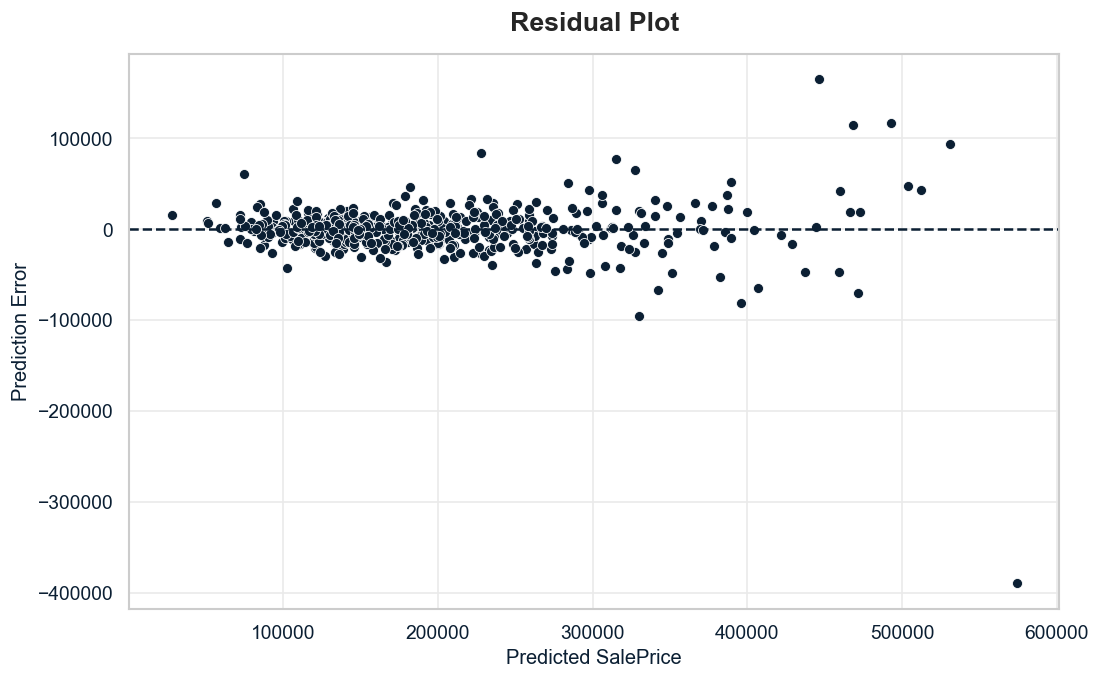

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=prediction_results["Predicted SalePrice"],y=prediction_results["Error"])
plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Predicted SalePrice", fontsize=12)
plt.ylabel("Prediction Error", fontsize=12)
plt.show()

In [57]:
prediction_results.sort_values(by="Absolute Error", ascending=False).head(10)

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
2181,184750,574249.086217,-389499.086217,389499.086217
44,611657,446581.272882,165075.727118,165075.727118
432,610000,492749.041678,117250.958322,117250.958322
433,582933,468477.544664,114455.455336,114455.455336
2246,235000,330265.930125,-95265.930125,95265.930125
2445,625000,531176.820875,93823.179125,93823.179125
1538,311500,227576.174416,83923.825584,83923.825584
2378,315000,396029.078262,-81029.078262,81029.078262
1559,392500,315020.775130,77479.224870,77479.224870
2335,401179,471302.267929,-70123.267929,70123.267929


### Final Model Evaluation Notes

The tuned Gradient Boosting model was evaluated on the untouched test set, which was not used during training, model comparison or hyperparameter tuning.

The final test performance was strong, with an R² score above 0.91. This means that the model was able to explain a large portion of the variation in house prices.

The final MAE shows that, on average, the model predictions are off by around $13.5k. The RMSE is higher because it penalizes larger errors more strongly, which is expected in a real estate dataset where expensive or unusual houses can be harder to predict.

The final test RMSE was higher than the cross-validation RMSE, suggesting that the test set contains some harder-to-predict observations. However, the model still generalized well overall.

The actual vs predicted plot shows that most predictions are close to the ideal diagonal line, especially for lower and mid-priced houses. Larger errors appear more often among high-value properties, which is common because expensive houses tend to have more unique characteristics.

The residual analysis shows that most errors are centered around zero, which is a positive sign. However, some extreme residuals remain, indicating that the model still struggles with a few unusual properties.

Overall, the tuned Gradient Boosting model provides solid predictive performance and is a strong final model for this project.

## 12. Model Interpretation

In this section, I will interpret the final tuned Gradient Boosting model using feature importance.

Feature importance helps identify which variables contributed the most to the model predictions. This is important because the goal of the project is not only to predict house prices, but also to understand which property characteristics are most relevant for price estimation.

Since the preprocessing pipeline creates transformed and one-hot encoded features, I will first extract the processed feature names and then analyze their importance in the final model.

In [58]:
fitted_preprocessor = best_gb_model.named_steps["preprocessor"]
fitted_model = best_gb_model.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of processed features: {len(feature_names)}")

Number of processed features: 321


In [59]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(20)

,Feature,Importance
13,num_median__Overall Qual,0.381980
36,num_median__TotalSF,0.336076
39,num_median__TotalBath,0.039415
37,num_median__HouseAge,0.027628
2,num_zero__Garage Cars,0.022033
12,num_median__Lot Area,0.018017
90,cat_none__Bsmt Qual_Ex,0.015547
290,cat_mode__Kitchen Qual_Ex,0.012327
4,num_zero__BsmtFin SF 1,0.011506
20,num_median__Gr Liv Area,0.010205


In [60]:
feature_importance_clean = feature_importance.copy()
feature_importance_clean["Feature"] = (
    feature_importance_clean["Feature"]
    .str.replace("num_zero__", "", regex=False)
    .str.replace("num_median__", "", regex=False)
    .str.replace("cat_none__", "", regex=False)
    .str.replace("cat_mode__", "", regex=False)
)

feature_importance_clean.head(20)

,Feature,Importance
13,Overall Qual,0.381980
36,TotalSF,0.336076
39,TotalBath,0.039415
37,HouseAge,0.027628
2,Garage Cars,0.022033
12,Lot Area,0.018017
90,Bsmt Qual_Ex,0.015547
290,Kitchen Qual_Ex,0.012327
4,BsmtFin SF 1,0.011506
20,Gr Liv Area,0.010205


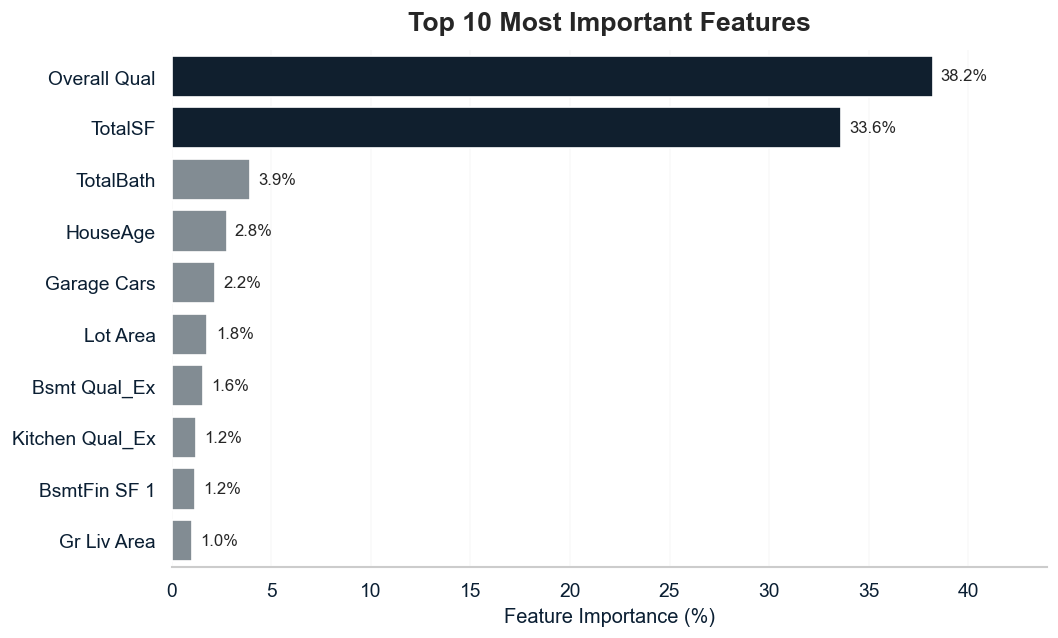

In [61]:
top_features = feature_importance_clean.head(10).copy()
top_features["Importance (%)"] = top_features["Importance"] * 100

bar_colors = [
    main_color if feature in ["Overall Qual", "TotalSF"] else secondary_color
    for feature in top_features["Feature"]
]

plt.figure(figsize=(9, 5.5), dpi=120)

ax = sns.barplot(
    data=top_features,
    x="Importance (%)",
    y="Feature",
    palette=bar_colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:.1f}%" for value in top_features["Importance (%)"]],
        padding=5,
        fontsize=10
    )

plt.title("Top 10 Most Important Features", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Feature Importance (%)", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.grid(axis="y", visible=False)
sns.despine(left=True)
plt.xlim(0, top_features["Importance (%)"].max() * 1.15)
plt.tight_layout()
plt.show()

The feature importance analysis shows that the model relies heavily on Overall Qual and TotalSF. This is consistent with the EDA findings, where house quality and total square footage appeared as the strongest price drivers.

The remaining features still contribute to the model, but with smaller individual importance. These variables capture additional property characteristics such as bathroom capacity, house age, garage capacity, lot size and quality-related attributes.

In [62]:
feature_importance_clean["Cumulative Importance"] = feature_importance_clean["Importance"].cumsum()
feature_importance_clean.head(20)

,Feature,Importance,Cumulative Importance
13,Overall Qual,0.381980,0.381980
36,TotalSF,0.336076,0.718056
39,TotalBath,0.039415,0.757470
37,HouseAge,0.027628,0.785098
2,Garage Cars,0.022033,0.807131
12,Lot Area,0.018017,0.825149
90,Bsmt Qual_Ex,0.015547,0.840696
290,Kitchen Qual_Ex,0.012327,0.853023
4,BsmtFin SF 1,0.011506,0.864528
20,Gr Liv Area,0.010205,0.874733


### Model Interpretation Notes

The feature importance analysis shows that the final Gradient Boosting model relies mainly on Overall Qual and TotalSF.

This result is consistent with the exploratory data analysis. Houses with better overall quality and larger total square footage tend to have higher sale prices, so it makes sense that the model gives strong importance to these features.

TotalBath, HouseAge, Garage Cars, Lot Area, Bsmt Qual_Ex, Kitchen Qual_Ex, Gr Liv Area and RemodAge also appear among the most important predictors. These variables represent important real estate price drivers, such as property size, construction quality, number of bathrooms, age, garage capacity, lot size, basement quality, kitchen quality and renovation status.

Another important point is that the top features explain a large share of the model importance. This suggests that the model is learning patterns that are not only predictive, but also aligned with real estate intuition.

Overall, the model is not behaving like a black box without context. Its most important features make business sense and confirm many of the patterns identified during the EDA.

In [63]:
artifacts_path = "../artifacts"
os.makedirs(artifacts_path, exist_ok=True)

In [64]:
model_path = os.path.join(artifacts_path, "final_gradient_boosting_model.pkl")
joblib.dump(best_gb_model, model_path)

print(f"Final model saved at: {model_path}")

Final model saved at: ../artifacts\final_gradient_boosting_model.pkl


In [65]:
final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [final_mae, final_rmse, final_r2]
})

metrics_path = os.path.join(artifacts_path, "final_model_metrics.csv")
final_metrics.to_csv(metrics_path, index=False)
final_metrics

,Metric,Value
0,MAE,13549.078501
1,RMSE,26044.028878
2,R2,0.915399


In [66]:
predictions_path = os.path.join(artifacts_path, "test_predictions.csv")
prediction_results.to_csv(predictions_path, index=False)

print(f"Test predictions saved at: {predictions_path}")

Test predictions saved at: ../artifacts\test_predictions.csv


In [67]:
loaded_model = joblib.load(model_path)
loaded_model_predictions = loaded_model.predict(X_test_fe)
predictions_match = np.allclose(y_test_pred, loaded_model_predictions)

print(f"Loaded model predictions match original predictions: {predictions_match}")

Loaded model predictions match original predictions: True


## 13. Final Conclusions

### Quick Results Summary

| Item | Result |
|---|---:|
| Final model | Tuned Gradient Boosting |
| Final Test MAE | $13,549.08 |
| Final Test RMSE | $26,044.03 |
| Final Test R² | 0.9154 |
| Best Cross-Validation RMSE | $20,315.60 |
| Main performance metric | RMSE |
| Most important features | Overall Qual, TotalSF, TotalBath, HouseAge |
| Saved artifacts | Final model, final metrics and test predictions |

This notebook completed the modeling stage of the House Prices Regression project.

The goal was to build a machine learning model capable of predicting residential house sale prices using the Ames Housing dataset. The final workflow included data cleaning, feature engineering, missing value treatment, preprocessing, model comparison, hyperparameter tuning, final evaluation, model interpretation and model saving.

The modeling process started by removing identifier columns that did not provide predictive information, such as Order and PID. Then, based on the EDA findings, a small number of influential observations with very large Gr Liv Area values were removed from the training set only. The test set remained untouched during the entire process to preserve a realistic final evaluation.

Feature engineering was an important part of the modeling pipeline. New variables such as TotalSF, HouseAge, RemodAge, TotalBath, HasGarage, HasBasement, HasFireplace and HasPool were created to better represent property size, age, renovation status, bathroom capacity and the presence of important property characteristics.

Missing values were treated according to their meaning. Some missing values represented the absence of a property characteristic, such as no garage, no basement, no fireplace, no pool, no fence or no alley access. These values were handled differently from truly unknown values, helping preserve useful information in the dataset.

All preprocessing steps were organized inside a ColumnTransformer and used within machine learning pipelines. This ensured that transformations such as imputation, scaling and one-hot encoding were applied consistently and helped prevent data leakage during cross-validation and model evaluation.

Several regression models were compared using 5-fold cross-validation. The Dummy Regressor was used as a naive baseline, while Ridge Regression, ElasticNet, Random Forest, Extra Trees and Gradient Boosting were tested as predictive models. Gradient Boosting achieved the best cross-validation performance and was selected for hyperparameter tuning.

After tuning, the final Gradient Boosting model was evaluated on the untouched test set. The model achieved a final MAE of $13,549.08, RMSE of $26,044.03 and R² of 0.9154. This means that the model was able to explain most of the variation in house prices and produced strong predictions on unseen data.

The final test RMSE was higher than the cross-validation RMSE, which suggests that the test set contained some harder-to-predict observations. However, the model still generalized well overall, especially considering the natural complexity of real estate pricing.

The prediction analysis showed that most predictions were close to the real sale prices, especially for lower and mid-priced houses. Larger errors appeared more often among expensive or unusual properties, which is expected because high-value homes often have unique characteristics that are harder to capture using structured tabular data.

The model interpretation step showed that Overall Qual and TotalSF were the most important features for the final model. This result is consistent with the exploratory analysis and makes business sense, since house quality and total square footage are two of the strongest drivers of property value. Other relevant features included TotalBath, HouseAge, Garage Cars, Lot Area, basement quality, kitchen quality, living area and remodeling age.

Overall, the final model delivered strong predictive performance and learned patterns that are aligned with real estate intuition. The project successfully transformed the insights from the EDA into a complete, reproducible and interpretable machine learning pipeline for house price prediction.

The final trained pipeline, evaluation metrics and test predictions were saved as project artifacts, allowing the model to be reused, documented and analyzed in future steps.